In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)

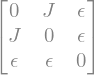

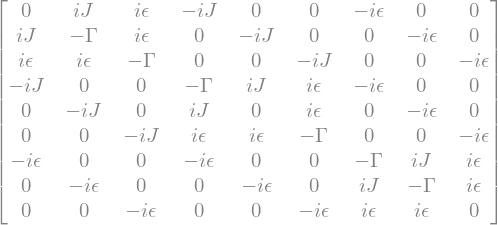

In [3]:
H = sp.Matrix([[0, J, epsilon], [J, 0, epsilon], [epsilon, epsilon, 0]])
L, rho = lindbladian(3, output=False, degenerate=True, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(9)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(9) for j in range(9)})

display(H)
display(L)

In [4]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ")

'{{0, I*J, I*ϵ, -I*J, 0, 0, -I*ϵ, 0, 0}, {I*J, -Γ, I*ϵ, 0, -I*J, 0, 0, -I*ϵ, 0}, {I*ϵ, I*ϵ, -Γ, 0, 0, -I*J, 0, 0, -I*ϵ}, {-I*J, 0, 0, -Γ, I*J, I*ϵ, -I*ϵ, 0, 0}, {0, -I*J, 0, I*J, 0, I*ϵ, 0, -I*ϵ, 0}, {0, 0, -I*J, I*ϵ, I*ϵ, -Γ, 0, 0, -I*ϵ}, {-I*ϵ, 0, 0, -I*ϵ, 0, 0, -Γ, I*J, I*ϵ}, {0, -I*ϵ, 0, 0, -I*ϵ, 0, I*J, -Γ, I*ϵ}, {0, 0, -I*ϵ, 0, 0, -I*ϵ, I*ϵ, I*ϵ, 0}}'

In [5]:
evals_string = '''
{0, -\[CapitalGamma], (-6*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2), ((-I)*((J - I*\[CapitalGamma])^2 + ((4*J - I*\[CapitalGamma])*\[Epsilon]^2)/J))/(J - I*\[CapitalGamma]), (I*((J + I*\[CapitalGamma])^2 + ((4*J + I*\[CapitalGamma])*\[Epsilon]^2)/J))/(J + I*\[CapitalGamma]), 
 (-I)*J - \[CapitalGamma] + (((6*I)*J + \[CapitalGamma])*\[Epsilon]^2)/(J*(3*J + I*\[CapitalGamma])), I*J - \[CapitalGamma] + (((-6*I)*J + \[CapitalGamma])*\[Epsilon]^2)/(J*(3*J - I*\[CapitalGamma])), 
 (-\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2] + (4*(24*J^2 + \[CapitalGamma]*(-\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon]^2)/(\[CapitalGamma]^2*(\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2]) + 2*J^2*(-8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])))/2, 
 (48*J^4 - 2*\[CapitalGamma]*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]^2 + J^2*(-3*\[CapitalGamma]^2 - 5*\[CapitalGamma]*Sqrt[-16*J^2 + \[CapitalGamma]^2] + 48*\[Epsilon]^2))/
  (\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - 2*J^2*(8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]))}
'''

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_653/3843698347.py:2: SyntaxWarning: invalid escape sequence '\['
  {0, -\[CapitalGamma], (-6*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2), ((-I)*((J - I*\[CapitalGamma])^2 + ((4*J - I*\[CapitalGamma])*\[Epsilon]^2)/J))/(J - I*\[CapitalGamma]), (I*((J + I*\[CapitalGamma])^2 + ((4*J + I*\[CapitalGamma])*\[Epsilon]^2)/J))/(J + I*\[CapitalGamma]),


# eigenvalues approximated to $O(\epsilon_i^3)$

++++++++++++++++++++++++++++++


++++++++++++++++++++++++++++++


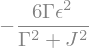

++++++++++++++++++++++++++++++


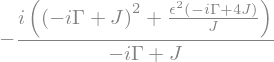

++++++++++++++++++++++++++++++


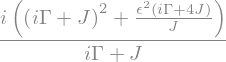

++++++++++++++++++++++++++++++


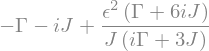

++++++++++++++++++++++++++++++


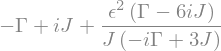

++++++++++++++++++++++++++++++


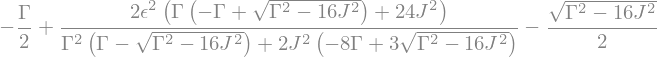

++++++++++++++++++++++++++++++


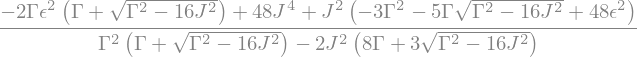

++++++++++++++++++++++++++++++


In [15]:
evals_approx = list(parse_mathematica(evals_string.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon")))

evals_approx = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon"): epsilon, sp.Symbol("J"):J}) for i in evals_approx]

for i in evals_approx:
    display(i)
    print("++++++++++++++++++++++++++++++")

# big $\Gamma$ limit

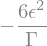

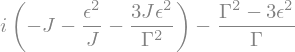

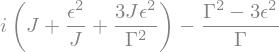

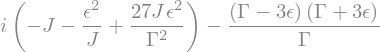

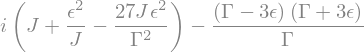

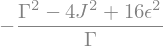

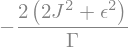

In [16]:
# big gamma limit - second order in eta=1/gamma
evals_big_gamma = []
for i in evals_approx:
    i = i.subs(gamma, 1/sp.Symbol('eta')).series(sp.Symbol('eta'), 0, 3).subs({sp.Symbol('eta'): 1/gamma}).removeO()
    evals_big_gamma.append(i)
    display(sp.Add((sp.re(i).factor()),sp.I*(sp.im(i)), evaluate=(True if sp.im(i)==0 else False)))
    

# small $\Gamma$ limit

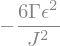

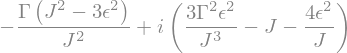

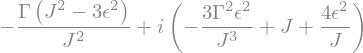

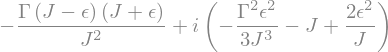

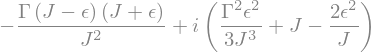

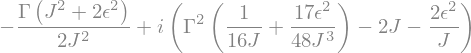

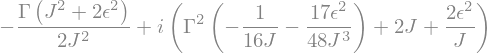

In [17]:
# small gamma limit - second order
evals_small_gamma = []
for i in evals_approx:
    i = i.series(gamma, 0, 3).removeO()
    evals_small_gamma.append(i)
    display(sp.Add((sp.re(i).factor()),sp.I*(sp.im(i)), evaluate=(True if sp.im(i)==0 else False)))

# eigenvectors

In [4]:
evecs = '''{{1, 0, 0, 0, 1, 0, 0, 0, 1}, {0, J/\[Epsilon], 1, J/\[Epsilon], 0, 1, 1, 1, 0}, {-1/2, (3*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2), (-3*\[Epsilon])/(2*(J - I*\[CapitalGamma])), (3*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2), -1/2, (-3*\[Epsilon])/(2*(J - I*\[CapitalGamma])), 
  (-3*\[Epsilon])/(2*(J + I*\[CapitalGamma])), (-3*\[Epsilon])/(2*(J + I*\[CapitalGamma])), 1}, {-1/2, (-(J^2*(J - I*\[CapitalGamma])) + (((-4*I)*J - \[CapitalGamma])*\[CapitalGamma]*\[Epsilon]^2)/(J - I*\[CapitalGamma]))/(2*J^3), 
  (J - I*\[CapitalGamma])/(2*\[Epsilon]) + ((4*J^2 + (3*I)*J*\[CapitalGamma] + \[CapitalGamma]^2)*\[Epsilon])/(4*J^2*(J - I*\[CapitalGamma])), (-(J^2*(J - I*\[CapitalGamma])^2) + ((-4*I)*J - \[CapitalGamma])*\[CapitalGamma]*\[Epsilon]^2)/(2*J^3*(J - I*\[CapitalGamma])), -1/2, 
  (J - I*\[CapitalGamma])/(2*\[Epsilon]) + ((4*J^2 + (3*I)*J*\[CapitalGamma] + \[CapitalGamma]^2)*\[Epsilon])/(4*J^2*(J - I*\[CapitalGamma])), ((-4*J + I*\[CapitalGamma])*\[Epsilon])/(4*J^2), ((-4*J + I*\[CapitalGamma])*\[Epsilon])/(4*J^2), 1}, 
 {-1/2, (-(J^2*(J + I*\[CapitalGamma])) + (((4*I)*J - \[CapitalGamma])*\[CapitalGamma]*\[Epsilon]^2)/(J + I*\[CapitalGamma]))/(2*J^3), -1/4*((4*J + I*\[CapitalGamma])*\[Epsilon])/J^2, (-(J^2*(J + I*\[CapitalGamma])^2) + ((4*I)*J - \[CapitalGamma])*\[CapitalGamma]*\[Epsilon]^2)/(2*J^3*(J + I*\[CapitalGamma])), 
  -1/2, -1/4*((4*J + I*\[CapitalGamma])*\[Epsilon])/J^2, (J + I*\[CapitalGamma])/(2*\[Epsilon]) + ((4*J^2 - (3*I)*J*\[CapitalGamma] + \[CapitalGamma]^2)*\[Epsilon])/(4*J^2*(J + I*\[CapitalGamma])), 
  (J + I*\[CapitalGamma])/(2*\[Epsilon]) + ((4*J^2 - (3*I)*J*\[CapitalGamma] + \[CapitalGamma]^2)*\[Epsilon])/(4*J^2*(J + I*\[CapitalGamma])), 1}, {(3*\[Epsilon])/(3*J + I*\[CapitalGamma]), ((-3*J + I*\[CapitalGamma])*\[Epsilon])/(J*(3*J + I*\[CapitalGamma])), 
  -1/2*(\[CapitalGamma]*\[Epsilon]^2)/(J^2*((-3*I)*J + \[CapitalGamma])), (3*J*\[Epsilon] - I*\[CapitalGamma]*\[Epsilon])/(3*J^2 + I*J*\[CapitalGamma]), (-3*\[Epsilon])/(3*J + I*\[CapitalGamma]), (\[CapitalGamma]*\[Epsilon]^2)/(2*J^2*((-3*I)*J + \[CapitalGamma])), -1, 1, 0}, 
 {(3*((2*I)*J^2 + ((12*J + I*\[CapitalGamma])*\[Epsilon]^2)/((3*I)*J + \[CapitalGamma])))/(\[CapitalGamma]*\[Epsilon]), -((2*J^2*(9*J^2 + \[CapitalGamma]^2) + (-36*J^2 - (9*I)*J*\[CapitalGamma] + \[CapitalGamma]^2)*\[Epsilon]^2)/(J*\[CapitalGamma]*((3*I)*J + \[CapitalGamma])*\[Epsilon])), 
  -2 + ((30*I)*J)/((3*I)*J + \[CapitalGamma]) - (2*J^2*((3*I)*J + \[CapitalGamma]))/(\[CapitalGamma]*\[Epsilon]^2) + ((1296*J^4 + (864*I)*J^3*\[CapitalGamma] - 279*J^2*\[CapitalGamma]^2 - (60*I)*J*\[CapitalGamma]^3 + \[CapitalGamma]^4)*\[Epsilon]^2)/(2*J^2*\[CapitalGamma]*((3*I)*J + \[CapitalGamma])^3), 
  (2*J^2*(9*J^2 + \[CapitalGamma]^2) + (-36*J^2 - (9*I)*J*\[CapitalGamma] + \[CapitalGamma]^2)*\[Epsilon]^2)/(J*\[CapitalGamma]*((3*I)*J + \[CapitalGamma])*\[Epsilon]), (3*((-2*I)*J^2 + (((-12*I)*J + \[CapitalGamma])*\[Epsilon]^2)/(-3*J + I*\[CapitalGamma])))/(\[CapitalGamma]*\[Epsilon]), 
  2 - ((30*I)*J)/((3*I)*J + \[CapitalGamma]) + (2*J^2*((3*I)*J + \[CapitalGamma]))/(\[CapitalGamma]*\[Epsilon]^2) + (((-1296*I)*J^4 + 864*J^3*\[CapitalGamma] + (279*I)*J^2*\[CapitalGamma]^2 - 60*J*\[CapitalGamma]^3 - I*\[CapitalGamma]^4)*\[Epsilon]^2)/(2*J^2*(3*J - I*\[CapitalGamma])^3*\[CapitalGamma]), 
  -1, 1, 0}, {((-2*I)*(6*J^2 + \[CapitalGamma]*(-\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])))/(((12*I)*J - \[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]) + 
   (((864*I)*J^4 + (2*I)*\[CapitalGamma]^3*Sqrt[-16*J^2 + \[CapitalGamma]^2] - 216*J^3*(2*\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - (18*I)*J^2*\[CapitalGamma]*(3*\[CapitalGamma] + 4*Sqrt[-16*J^2 + \[CapitalGamma]^2]) + 
      3*J*\[CapitalGamma]^2*(9*\[CapitalGamma] + 7*Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon])/(144*J^4*\[CapitalGamma] + 7*J^2*\[CapitalGamma]^3 - \[CapitalGamma]^5), 
  (((60*I)*J^2)/\[CapitalGamma] + (6*(396*J^3 - (15*I)*\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) + (30*I)*J^2*(8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]) - J*\[CapitalGamma]*(31*\[CapitalGamma] + 45*Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon]^2)/
     (Sqrt[-16*J^2 + \[CapitalGamma]^2]*(9*J^2*\[CapitalGamma] + \[CapitalGamma]^3)) + J*(5 - (3*(-80*J^2 + 5*\[CapitalGamma]^2 + 8*\[Epsilon]^2))/(\[CapitalGamma]*Sqrt[-16*J^2 + \[CapitalGamma]^2])))/(10*\[Epsilon]), 
  (4*\[CapitalGamma]*(144*J^4 + 4*\[CapitalGamma]^3*(\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2]) + J^2*\[CapitalGamma]*(-73*\[CapitalGamma] + 39*Sqrt[-16*J^2 + \[CapitalGamma]^2]) - (36*I)*J*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]^2))/
   (((-12*I)*J + \[CapitalGamma] - 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])^2*(\[CapitalGamma]^2*(\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2]) + 2*J^2*(-8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]))), 
  (((-60*I)*J^2)/\[CapitalGamma] + (6*(-396*J^3 + (15*I)*\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - (30*I)*J^2*(8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]) + J*\[CapitalGamma]*(31*\[CapitalGamma] + 45*Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon]^2)/
     (Sqrt[-16*J^2 + \[CapitalGamma]^2]*(9*J^2*\[CapitalGamma] + \[CapitalGamma]^3)) + J*(-5 + (3*(-80*J^2 + 5*\[CapitalGamma]^2 + 8*\[Epsilon]^2))/(\[CapitalGamma]*Sqrt[-16*J^2 + \[CapitalGamma]^2])))/(10*\[Epsilon]), 
  ((2*I)*(6*J^2 + \[CapitalGamma]*(-\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])))/(((12*I)*J - \[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]) + 
   (((-864*I)*J^4 - (2*I)*\[CapitalGamma]^3*Sqrt[-16*J^2 + \[CapitalGamma]^2] + 216*J^3*(2*\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) + (18*I)*J^2*\[CapitalGamma]*(3*\[CapitalGamma] + 4*Sqrt[-16*J^2 + \[CapitalGamma]^2]) - 
      3*J*\[CapitalGamma]^2*(9*\[CapitalGamma] + 7*Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon])/(144*J^4*\[CapitalGamma] + 7*J^2*\[CapitalGamma]^3 - \[CapitalGamma]^5), 
  (4*\[CapitalGamma]*(144*J^4 + 4*\[CapitalGamma]^3*(\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2]) + J^2*\[CapitalGamma]*(-73*\[CapitalGamma] + 39*Sqrt[-16*J^2 + \[CapitalGamma]^2]) - (36*I)*J*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]^2))/
   (((-12*I)*J + \[CapitalGamma] - 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])^2*(J^2*(16*\[CapitalGamma] - 6*Sqrt[-16*J^2 + \[CapitalGamma]^2]) + \[CapitalGamma]^2*(-\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]))), -1, 1, 0}, 
 {((-2*I)*(-6*J^2 + \[CapitalGamma]*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])))/(((-12*I)*J + \[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]) + 
   (((864*I)*J^4 - (2*I)*\[CapitalGamma]^3*Sqrt[-16*J^2 + \[CapitalGamma]^2] + 3*J*\[CapitalGamma]^2*(9*\[CapitalGamma] - 7*Sqrt[-16*J^2 + \[CapitalGamma]^2]) + 216*J^3*(-2*\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) + 
      (18*I)*J^2*\[CapitalGamma]*(-3*\[CapitalGamma] + 4*Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon])/(144*J^4*\[CapitalGamma] + 7*J^2*\[CapitalGamma]^3 - \[CapitalGamma]^5), (J*((12*I)*J + \[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]))/(2*\[CapitalGamma]*\[Epsilon]) + 
   (24*J*((288*I)*J^3 + 4*\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - 24*J^2*(2*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]) - (3*I)*J*\[CapitalGamma]*(5*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon])/
    (((-12*I)*J + \[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])^2*(-(\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])) + 2*J^2*(8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]))), 
  (4*\[CapitalGamma]*(144*J^4 + 4*\[CapitalGamma]^3*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - J^2*\[CapitalGamma]*(73*\[CapitalGamma] + 39*Sqrt[-16*J^2 + \[CapitalGamma]^2]) + (36*I)*J*(-\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]^2))/
   (((-12*I)*J + \[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])^2*(\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - 2*J^2*(8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]))), 
  (J*(-(((-12*I)*J + \[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])*(5*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])) + 
     (24*((-288*I)*J^3 - 4*\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) + 24*J^2*(2*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]) + (3*I)*J*\[CapitalGamma]*(5*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon]^2)/
      (-(\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])) + 2*J^2*(8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]))))/(((-12*I)*J + \[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])^2*\[Epsilon]), 
  ((2*I)*(-6*J^2 + \[CapitalGamma]*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])))/(((-12*I)*J + \[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]) + 
   (((-864*I)*J^4 + (2*I)*\[CapitalGamma]^3*Sqrt[-16*J^2 + \[CapitalGamma]^2] - 216*J^3*(-2*\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - (18*I)*J^2*\[CapitalGamma]*(-3*\[CapitalGamma] + 4*Sqrt[-16*J^2 + \[CapitalGamma]^2]) + 
      3*J*\[CapitalGamma]^2*(-9*\[CapitalGamma] + 7*Sqrt[-16*J^2 + \[CapitalGamma]^2]))*\[Epsilon])/(144*J^4*\[CapitalGamma] + 7*J^2*\[CapitalGamma]^3 - \[CapitalGamma]^5), 
  (4*\[CapitalGamma]*(144*J^4 + 4*\[CapitalGamma]^3*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - J^2*\[CapitalGamma]*(73*\[CapitalGamma] + 39*Sqrt[-16*J^2 + \[CapitalGamma]^2]) + (36*I)*J*(-\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]^2))/
   (((-12*I)*J + \[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])^2*(-(\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])) + 2*J^2*(8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2]))), -1, 1, 0}}'''

<>:1: SyntaxWarning: invalid escape sequence '\['
<>:1: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_137/2680941187.py:1: SyntaxWarning: invalid escape sequence '\['
  evecs = '''{{1, 0, 0, 0, 1, 0, 0, 0, 1}, {0, J/\[Epsilon], 1, J/\[Epsilon], 0, 1, 1, 1, 0}, {-1/2, (3*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2), (-3*\[Epsilon])/(2*(J - I*\[CapitalGamma])), (3*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2), -1/2, (-3*\[Epsilon])/(2*(J - I*\[CapitalGamma])),


++++++++++++++++++++++++++++++


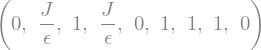

++++++++++++++++++++++++++++++


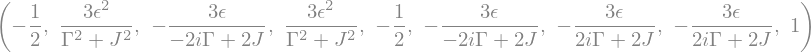

++++++++++++++++++++++++++++++


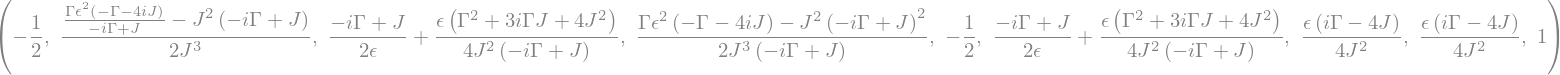

++++++++++++++++++++++++++++++


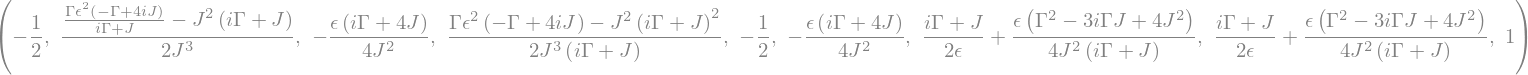

++++++++++++++++++++++++++++++


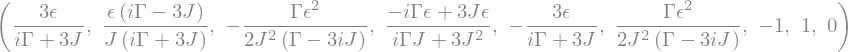

++++++++++++++++++++++++++++++


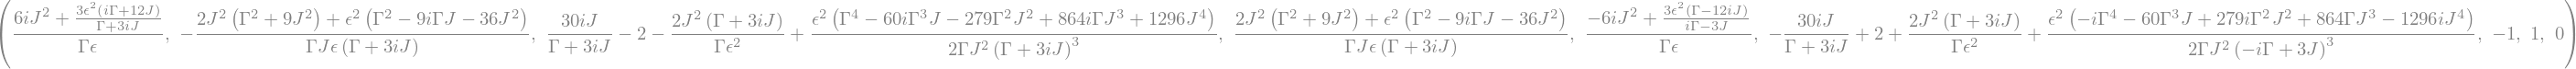

++++++++++++++++++++++++++++++


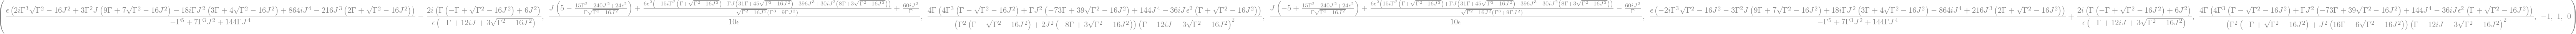

++++++++++++++++++++++++++++++


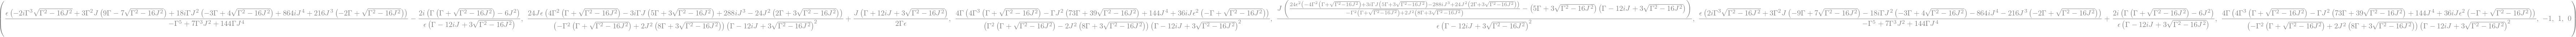

++++++++++++++++++++++++++++++


In [5]:
evecs_approx = list(parse_mathematica(evecs.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon")))

evecs_approx = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon"): epsilon, sp.Symbol("J"):J}) for i in evecs_approx]

for i in evecs_approx:
    display(i)
    print("++++++++++++++++++++++++++++++")

In [15]:

for i in evecs_approx:
    display(sp.Matrix(i).applyfunc(lambda n: sp.Symbol('\\ast') if not (n==0) else n).T)

In [17]:

for i in evecs_approx:
    display(sp.Matrix(i).applyfunc(lambda n: sp.Symbol('\\ast') if not (n.is_rational) else n).T)

# eigenvalue splitting

In [8]:
evals_exact_string = '''
{0, -\[CapitalGamma], (-2*\[CapitalGamma])/3 - (2^(1/3)*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2))/(3*(18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2 + Sqrt[4*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2)^3 + (18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2)^2])^
     (1/3)) + (18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2 + Sqrt[4*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2)^3 + (18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2)^2])^(1/3)/(3*2^(1/3)), 
 (-2*\[CapitalGamma])/3 + ((1 + I*Sqrt[3])*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2))/
   (3*2^(2/3)*(18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2 + Sqrt[4*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2)^3 + (18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2)^2])^(1/3)) - 
  ((1 - I*Sqrt[3])*(18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2 + Sqrt[4*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2)^3 + (18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2)^2])^(1/3))/(6*2^(1/3)), 
 (-2*\[CapitalGamma])/3 + ((1 - I*Sqrt[3])*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2))/
   (3*2^(2/3)*(18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2 + Sqrt[4*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2)^3 + (18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2)^2])^(1/3)) - 
  ((1 + I*Sqrt[3])*(18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2 + Sqrt[4*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2)^3 + (18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2)^2])^(1/3))/(6*2^(1/3)), 
 (-3*\[CapitalGamma])/4 - Sqrt[-5*J^2 - (3*\[CapitalGamma]^2)/4 - 4*\[Epsilon]^2 + (5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2)/3 + (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
      (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
         Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
           4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
           864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) + 
     (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
        Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
          4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
          864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3))]/2 - 
  Sqrt[-5*J^2 + (3*\[CapitalGamma]^2)/2 - 4*\[Epsilon]^2 + (-5*J^2 - 3*\[CapitalGamma]^2 - 4*\[Epsilon]^2)/3 - (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
      (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
         Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
           4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
           864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) - 
     (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
        Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
          4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
          864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3)) - 
     (-27*\[CapitalGamma]^3 + 12*\[CapitalGamma]*(5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2) - 8*(9*J^2*\[CapitalGamma] + \[CapitalGamma]^3 + 6*\[CapitalGamma]*\[Epsilon]^2))/
      (4*Sqrt[-5*J^2 - (3*\[CapitalGamma]^2)/4 - 4*\[Epsilon]^2 + (5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2)/3 + (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
          (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
             Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
               4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 864*
                \[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) + 
         (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
            Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
              4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
              864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3))])]/2, 
 (-3*\[CapitalGamma])/4 - Sqrt[-5*J^2 - (3*\[CapitalGamma]^2)/4 - 4*\[Epsilon]^2 + (5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2)/3 + (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
      (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
         Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
           4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
           864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) + 
     (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
        Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
          4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
          864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3))]/2 + 
  Sqrt[-5*J^2 + (3*\[CapitalGamma]^2)/2 - 4*\[Epsilon]^2 + (-5*J^2 - 3*\[CapitalGamma]^2 - 4*\[Epsilon]^2)/3 - (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
      (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
         Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
           4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
           864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) - 
     (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
        Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
          4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
          864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3)) - 
     (-27*\[CapitalGamma]^3 + 12*\[CapitalGamma]*(5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2) - 8*(9*J^2*\[CapitalGamma] + \[CapitalGamma]^3 + 6*\[CapitalGamma]*\[Epsilon]^2))/
      (4*Sqrt[-5*J^2 - (3*\[CapitalGamma]^2)/4 - 4*\[Epsilon]^2 + (5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2)/3 + (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
          (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
             Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
               4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 864*
                \[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) + 
         (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
            Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
              4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
              864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3))])]/2, 
 (-3*\[CapitalGamma])/4 + Sqrt[-5*J^2 - (3*\[CapitalGamma]^2)/4 - 4*\[Epsilon]^2 + (5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2)/3 + (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
      (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
         Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
           4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
           864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) + 
     (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
        Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
          4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
          864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3))]/2 - 
  Sqrt[-5*J^2 + (3*\[CapitalGamma]^2)/2 - 4*\[Epsilon]^2 + (-5*J^2 - 3*\[CapitalGamma]^2 - 4*\[Epsilon]^2)/3 - (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
      (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
         Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
           4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
           864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) - 
     (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
        Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
          4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
          864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3)) + 
     (-27*\[CapitalGamma]^3 + 12*\[CapitalGamma]*(5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2) - 8*(9*J^2*\[CapitalGamma] + \[CapitalGamma]^3 + 6*\[CapitalGamma]*\[Epsilon]^2))/
      (4*Sqrt[-5*J^2 - (3*\[CapitalGamma]^2)/4 - 4*\[Epsilon]^2 + (5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2)/3 + (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
          (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
             Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
               4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 864*
                \[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) + 
         (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
            Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
              4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
              864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3))])]/2, 
 (-3*\[CapitalGamma])/4 + Sqrt[-5*J^2 - (3*\[CapitalGamma]^2)/4 - 4*\[Epsilon]^2 + (5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2)/3 + (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
      (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
         Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
           4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
           864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) + 
     (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
        Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
          4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
          864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3))]/2 + 
  Sqrt[-5*J^2 + (3*\[CapitalGamma]^2)/2 - 4*\[Epsilon]^2 + (-5*J^2 - 3*\[CapitalGamma]^2 - 4*\[Epsilon]^2)/3 - (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
      (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
         Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
           4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
           864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) - 
     (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
        Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
          4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
          864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3)) + 
     (-27*\[CapitalGamma]^3 + 12*\[CapitalGamma]*(5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2) - 8*(9*J^2*\[CapitalGamma] + \[CapitalGamma]^3 + 6*\[CapitalGamma]*\[Epsilon]^2))/
      (4*Sqrt[-5*J^2 - (3*\[CapitalGamma]^2)/4 - 4*\[Epsilon]^2 + (5*J^2 + 3*\[CapitalGamma]^2 + 4*\[Epsilon]^2)/3 + (2^(1/3)*(73*J^4 - 3*J^2*\[CapitalGamma]^2 - 56*J^2*\[Epsilon]^2 - 6*\[CapitalGamma]^2*\[Epsilon]^2 + 64*\[Epsilon]^4))/
          (3*(-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
             Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
               4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 864*
                \[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)) + 
         (-1190*J^6 + 90*J^4*\[CapitalGamma]^2 + 2328*J^4*\[Epsilon]^2 - 234*J^2*\[CapitalGamma]^2*\[Epsilon]^2 + 1344*J^2*\[Epsilon]^4 + 144*\[CapitalGamma]^2*\[Epsilon]^4 - 1024*\[Epsilon]^6 + 
            Sqrt[-139968*J^12 - 22356*J^10*\[CapitalGamma]^2 + 216*J^8*\[CapitalGamma]^4 + 108*J^6*\[CapitalGamma]^6 - 1959552*J^10*\[Epsilon]^2 + 1065312*J^8*\[CapitalGamma]^2*\[Epsilon]^2 - 67608*J^6*\[CapitalGamma]^4*\[Epsilon]^2 + 648*J^4*\[CapitalGamma]^6*\[Epsilon]^2 - 
              4618944*J^8*\[Epsilon]^4 - 1329696*J^6*\[CapitalGamma]^2*\[Epsilon]^4 + 66420*J^4*\[CapitalGamma]^4*\[Epsilon]^4 + 1296*J^2*\[CapitalGamma]^6*\[Epsilon]^4 + 15676416*J^6*\[Epsilon]^6 + 497664*J^4*\[CapitalGamma]^2*\[Epsilon]^6 - 70848*J^2*\[CapitalGamma]^4*\[Epsilon]^6 + 
              864*\[CapitalGamma]^6*\[Epsilon]^6 - 8957952*J^4*\[Epsilon]^8 + 497664*J^2*\[CapitalGamma]^2*\[Epsilon]^8 - 6912*\[CapitalGamma]^4*\[Epsilon]^8])^(1/3)/(3*2^(1/3))])]/2}
'''

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_396/1602762430.py:2: SyntaxWarning: invalid escape sequence '\['
  {0, -\[CapitalGamma], (-2*\[CapitalGamma])/3 - (2^(1/3)*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2))/(3*(18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2 + Sqrt[4*(3*J^2 - \[CapitalGamma]^2 + 24*\[Epsilon]^2)^3 + (18*J^2*\[CapitalGamma] + 2*\[CapitalGamma]^3 - 18*\[CapitalGamma]*\[Epsilon]^2)^2])^


In [9]:
# parsing eigenvalues EXCATLY (unlike above, where all eigen- values and vectors were Taylor expanded)
evals_exact = list(parse_mathematica(evals_exact_string.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon")))
evals_exact = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon"): epsilon, sp.Symbol("J"):J}) for i in evals_exact]


# had to run the code below natively, otherwise it overloads jupyter's kernel --> kernel shutdown

0: 1/9
0: 2/9
0: 3/9
0: 4/9
0: 5/9
0: 6/9
0: 7/9
0: 8/9
0: 9/9
1: 1/9
1: 2/9
1: 3/9
1: 4/9
1: 5/9
1: 6/9
1: 7/9
1: 8/9
1: 9/9
2: 1/9
2: 2/9
2: 3/9
2: 4/9
2: 5/9
2: 6/9
2: 7/9
2: 8/9
2: 9/9


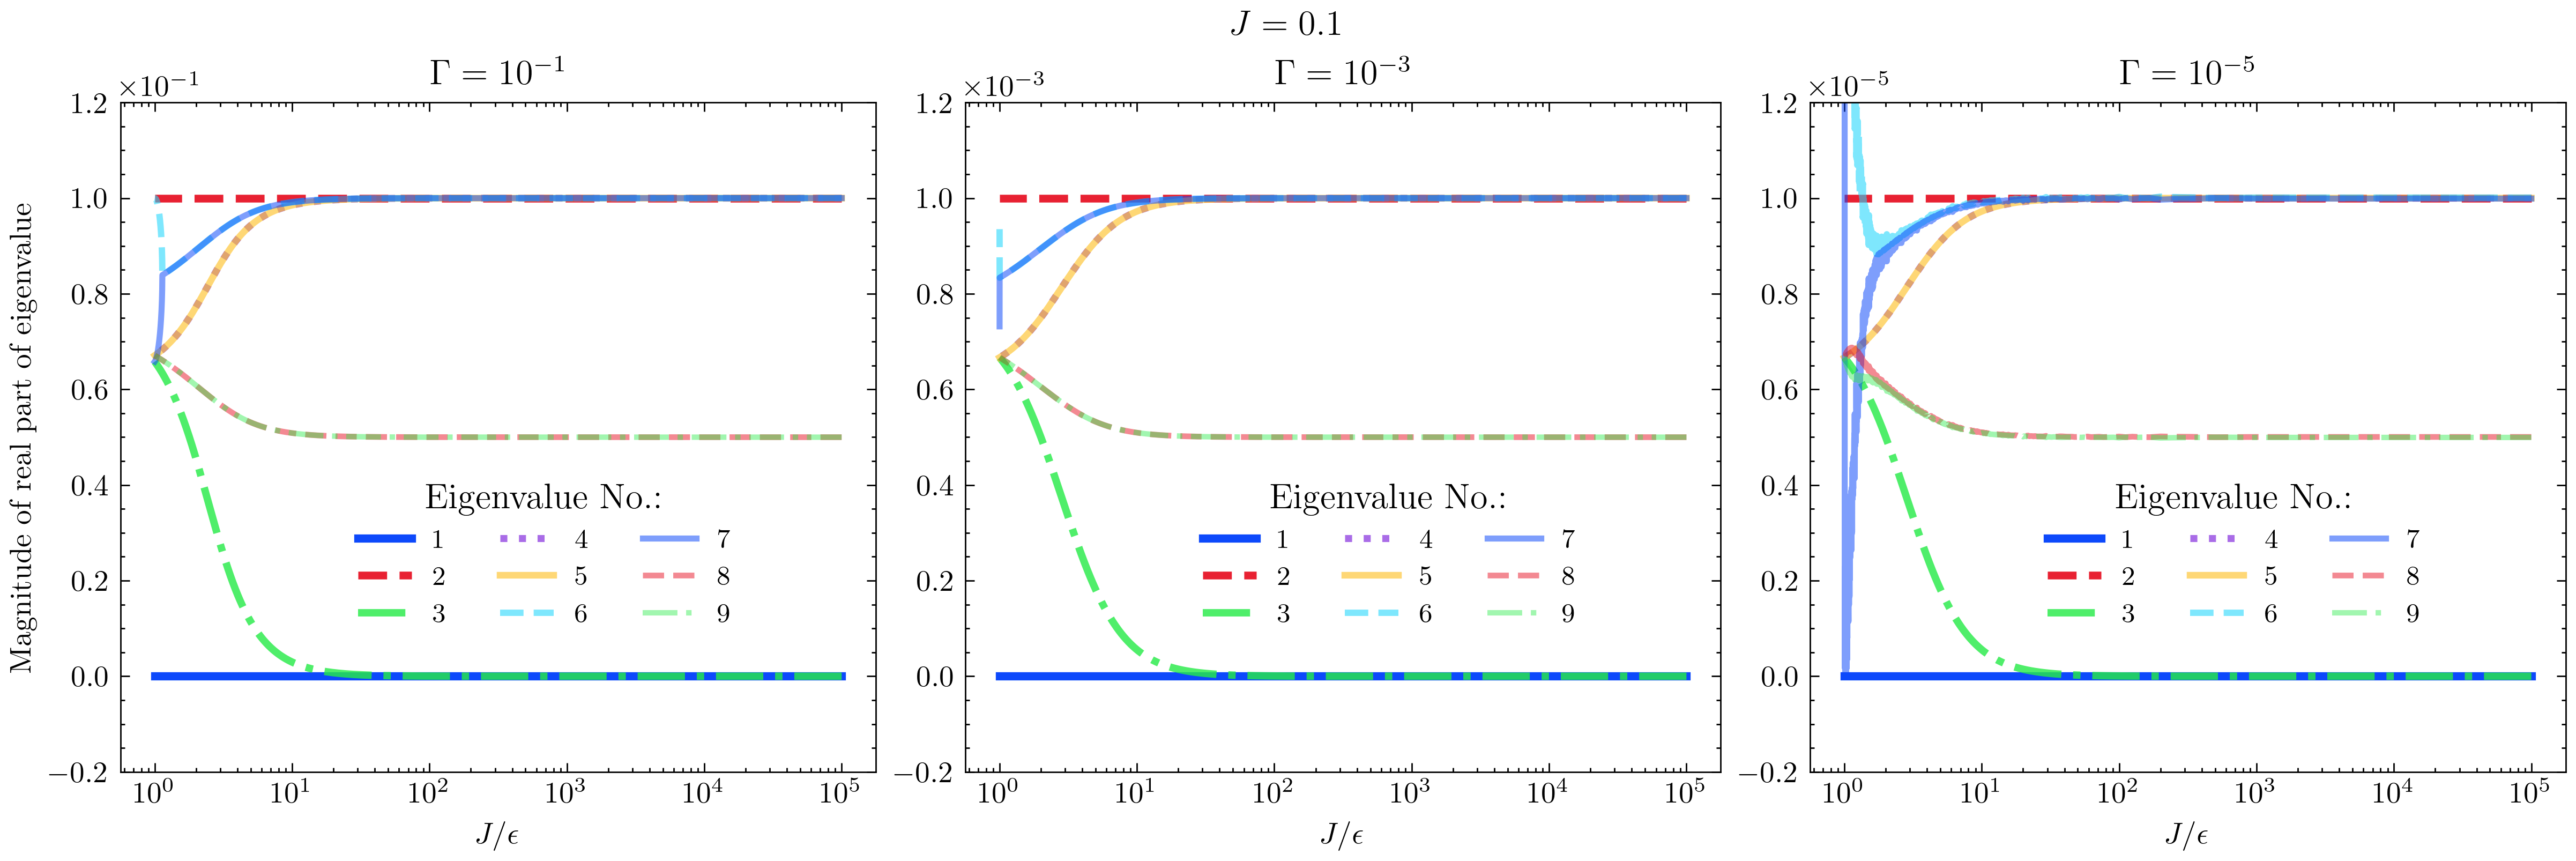

In [13]:


fig, axs = plt.subplots(1,3, figsize=(12, 4), layout='constrained')


gamma_vals = [1e-1, 1e-3, 1e-5]
J_val = 0.1
epsilon_start = 1e-6
epsilon_stop = J_val
step = 1e-4

plt.style.use(['science', 'high-vis'])

for col, gamma_val in enumerate(gamma_vals):
    for i in range(0, 9):
        print(f"{col}: {i+1}/9")
        x, y = compute_eq_ana(evals_exact[i].subs({J:J_val, gamma:gamma_val, epsilon:epsilon}),
                              epsilon, 
                              epsilon_start,
                              epsilon_stop,
                              step)
        
        axs[col].plot(J_val/x, 
                    np.abs(np.real(y)),
                    label=f"{i+1}",
                    linewidth=2.75*0.95**i,
                    alpha=1*0.9**i)

    axs[col].legend(title='Eigenvalue No.:', title_fontsize=12, fontsize=9, ncol=3, loc=(0.3, 0.2)) # plotting legend
    axs[col].set_xscale('log') # setting log scale for x axis
    axs[col].set_xlabel(r"$J / \epsilon$") # labelling x axis
    #axs[col].invert_xaxis() # inverting x axis
    axs[col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    axs[col].set_ylim([-1*gamma_val*0.2, gamma_val*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gamma_val))}}}$')

axs[0].set_ylabel('Magnitude of real part of eigenvalue')  # labelling y axis
#fig.title('Eigenvalues of single-body, three-site (degenerate), symmetric-case\n' + fr'$\Gamma={gamma_val}$, $J={J_val}$')
fig.suptitle(fr'$J={J_val}$')   

fig.savefig("splitting.pdf")